In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split


In [10]:

# Load MNIST
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist["data"].astype(np.float32)     # (70000, 784)
y = mnist["target"].astype(int)

# Simple normalisation
X /= 255.0

# Train / test split for model selection vs final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape


((56000, 784), (14000, 784))

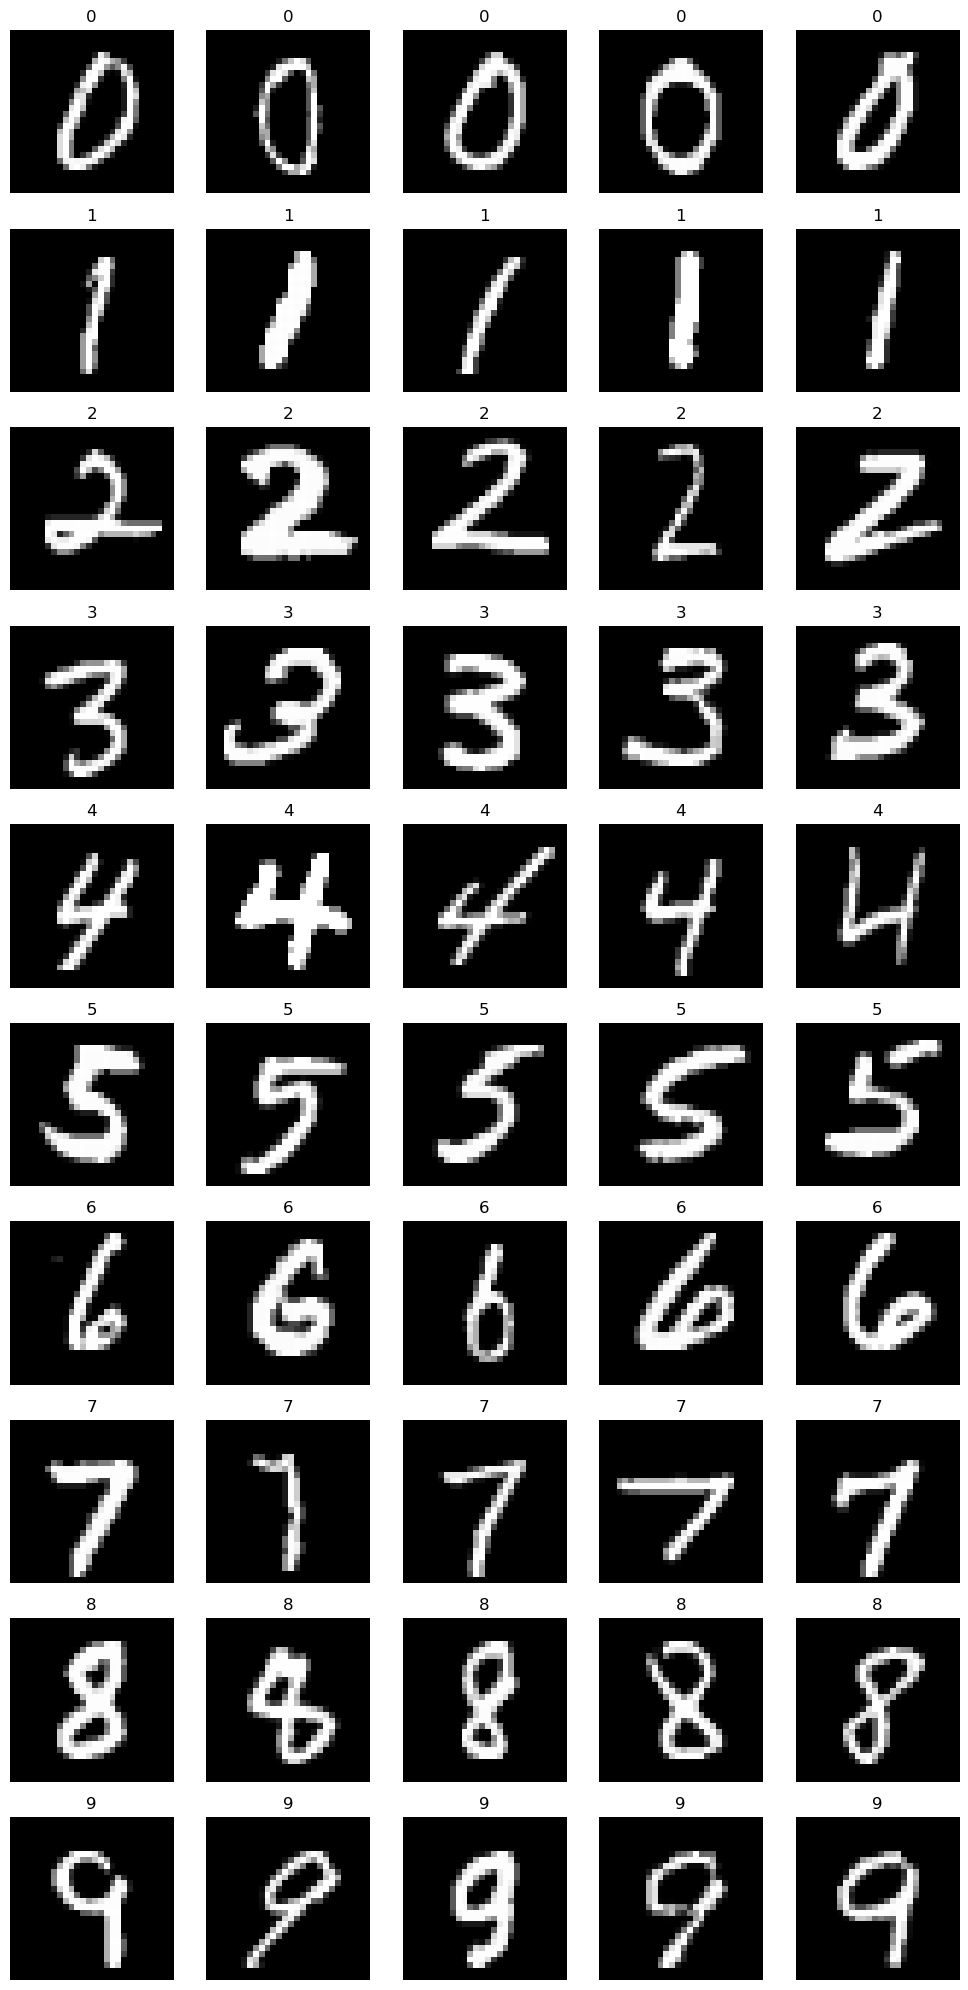

In [ ]:
# Plot a quick sanity-check grid: for each true digit class (0–9), show n_per_class
# random training images. This helps visualise within-class variation before clustering.

def plot_samples_per_class(X, y, n_per_class=5):
    classes = np.unique(y)
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class*2, 2*len(classes)))

    for row, cls in enumerate(classes):
        idx = np.where(y == cls)[0]
        chosen = np.random.choice(idx, n_per_class, replace=False)
        for col, i in enumerate(chosen):
            ax = axes[row, col]
            ax.imshow(X[i].reshape(28, 28), cmap="gray")
            ax.set_title(str(cls))
            ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_samples_per_class(X_train, y_train, n_per_class=5)


In [12]:
def apply_pca(X_train, X_test, n_components):
    pca = PCA(n_components=n_components, random_state=42)
    Xtr_p = pca.fit_transform(X_train)
    Xte_p = pca.transform(X_test)
    explained = pca.explained_variance_ratio_.sum()
    print(f"PCA with {n_components} components, explained variance = {explained:.3f}")
    return pca, Xtr_p, Xte_p


In [13]:
def eval_clustering(X, y_true, y_pred):
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    sil = silhouette_score(X, y_pred)
    return {"ARI": ari, "NMI": nmi, "Silhouette": sil}


In [ ]:
# Grid search over K-Means hyperparameters.
# For each PCA dimensionality and number of clusters k, fit K-Means on the
# PCA-transformed training data and evaluate clustering quality using ARI,
# NMI, and Silhouette score. Results are stored for later comparison.

pca_dims_list = [20, 50, 100]
k_list = [10, 15, 20]

kmeans_results = []

for n_dim in pca_dims_list:
    _, Xtr_p, _ = apply_pca(X_train, X_train, n_dim)

    for k in k_list:
        km = KMeans(
            n_clusters=k,
            n_init=10,
            max_iter=300,
            random_state=42,
        )
        km.fit(Xtr_p)
        labels = km.labels_

        scores = eval_clustering(Xtr_p, y_train, labels)
        scores.update({"pca_dims": n_dim, "n_clusters": k})
        kmeans_results.append(scores)
        print("KMeans:", scores)


PCA with 20 components, explained variance = 0.645
KMeans: {'ARI': 0.3565317743569559, 'NMI': 0.4895205456853388, 'Silhouette': 0.12403801828622818, 'pca_dims': 20, 'n_clusters': 10}
KMeans: {'ARI': 0.37426268564713416, 'NMI': 0.5315353903520281, 'Silhouette': 0.12850840389728546, 'pca_dims': 20, 'n_clusters': 15}
KMeans: {'ARI': 0.3663517543950788, 'NMI': 0.5618734937567096, 'Silhouette': 0.13468505442142487, 'pca_dims': 20, 'n_clusters': 20}
PCA with 50 components, explained variance = 0.825
KMeans: {'ARI': 0.3626892827879775, 'NMI': 0.4974714816936566, 'Silhouette': 0.0853116512298584, 'pca_dims': 50, 'n_clusters': 10}
KMeans: {'ARI': 0.37818885580369066, 'NMI': 0.5363936613800201, 'Silhouette': 0.09070587903261185, 'pca_dims': 50, 'n_clusters': 15}
KMeans: {'ARI': 0.3496789654960953, 'NMI': 0.5471476848139757, 'Silhouette': 0.09584374725818634, 'pca_dims': 50, 'n_clusters': 20}
PCA with 100 components, explained variance = 0.915
KMeans: {'ARI': 0.36392799861138975, 'NMI': 0.4983836

In [ ]:
# Select the best K-Means configuration based on training ARI
# (used as the main model-selection criterion).

best_km_cfg = max(kmeans_results, key=lambda d: d["ARI"])
best_km_cfg


{'ARI': 0.3784940898382149,
 'NMI': 0.5366225570029959,
 'Silhouette': 0.07518584281206131,
 'pca_dims': 100,
 'n_clusters': 15}

In [ ]:
# Refit K-Means using the selected best hyperparameters on the full training set,
# then evaluate clustering performance on both the training and test splits.

best_dim_km = best_km_cfg["pca_dims"]
best_k_km   = best_km_cfg["n_clusters"]

pca_km, Xtr_best_km, Xte_best_km = apply_pca(X_train, X_test, best_dim_km)

kmeans_best = KMeans(
    n_clusters=best_k_km,
    n_init=10,
    max_iter=300,
    random_state=42,
)
kmeans_best.fit(Xtr_best_km)

train_labels_km = kmeans_best.labels_
test_labels_km  = kmeans_best.predict(Xte_best_km)

print("KMeans train:", eval_clustering(Xtr_best_km, y_train, train_labels_km))
print("KMeans test:",  eval_clustering(Xte_best_km, y_test,  test_labels_km))


PCA with 100 components, explained variance = 0.915
KMeans train: {'ARI': 0.3784940898382149, 'NMI': 0.5366225570029959, 'Silhouette': 0.07518584281206131}
KMeans test: {'ARI': 0.3801768855019568, 'NMI': 0.5379612483682102, 'Silhouette': 0.07774430513381958}


In [ ]:
# Grid search over GMM hyperparameters.
# For each PCA dimensionality, number of mixture components, and covariance type,
# fit a Gaussian Mixture Model on the PCA-transformed training data and evaluate
# clustering quality using ARI, NMI, and Silhouette score. Results are stored
# for model selection.

pca_dims_list = [20, 50, 100]
components_list = [10, 15, 20]
cov_types = ["full", "diag"]

gmm_results = []

for n_dim in pca_dims_list:
    _, Xtr_p, _ = apply_pca(X_train, X_train, n_dim)

    for n_comp in components_list:
        for cov in cov_types:
            gmm = GaussianMixture(
                n_components=n_comp,
                covariance_type=cov,
                reg_covar=1e-6,                                                                                                 
                random_state=42,
            )
            gmm.fit(Xtr_p)
            labels = gmm.predict(Xtr_p)

            scores = eval_clustering(Xtr_p, y_train, labels)
            scores.update({
                "pca_dims": n_dim,
                "n_components": n_comp,
                "covariance_type": cov,
            })
            gmm_results.append(scores)
            print("GMM:", scores)


PCA with 20 components, explained variance = 0.645
GMM: {'ARI': 0.48779464752013224, 'NMI': 0.6366273077920044, 'Silhouette': 0.09046421945095062, 'pca_dims': 20, 'n_components': 10, 'covariance_type': 'full'}
GMM: {'ARI': 0.3393166775330425, 'NMI': 0.5213174202646753, 'Silhouette': 0.09239087253808975, 'pca_dims': 20, 'n_components': 10, 'covariance_type': 'diag'}
GMM: {'ARI': 0.47239065814591075, 'NMI': 0.6659898299714498, 'Silhouette': 0.08092308044433594, 'pca_dims': 20, 'n_components': 15, 'covariance_type': 'full'}
GMM: {'ARI': 0.38371884083707714, 'NMI': 0.5658190198533741, 'Silhouette': 0.09049302339553833, 'pca_dims': 20, 'n_components': 15, 'covariance_type': 'diag'}
GMM: {'ARI': 0.4129809230299167, 'NMI': 0.6368368966422692, 'Silhouette': 0.08558965474367142, 'pca_dims': 20, 'n_components': 20, 'covariance_type': 'full'}
GMM: {'ARI': 0.3308227164688408, 'NMI': 0.5593521855884603, 'Silhouette': 0.09867417812347412, 'pca_dims': 20, 'n_components': 20, 'covariance_type': 'diag'

/opt/anaconda3/envs/ml_pymc/lib/python3.11/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


GMM: {'ARI': 0.36569389822876613, 'NMI': 0.6065547445516858, 'Silhouette': 0.04442039132118225, 'pca_dims': 50, 'n_components': 20, 'covariance_type': 'full'}
GMM: {'ARI': 0.2533193971049044, 'NMI': 0.5216642070365682, 'Silhouette': 0.04340031370520592, 'pca_dims': 50, 'n_components': 20, 'covariance_type': 'diag'}
PCA with 100 components, explained variance = 0.915
GMM: {'ARI': 0.3694744202042941, 'NMI': 0.5309539956882466, 'Silhouette': 0.026997096836566925, 'pca_dims': 100, 'n_components': 10, 'covariance_type': 'full'}
GMM: {'ARI': 0.2566288529009582, 'NMI': 0.4767341376144578, 'Silhouette': 0.017124369740486145, 'pca_dims': 100, 'n_components': 10, 'covariance_type': 'diag'}
GMM: {'ARI': 0.33456155656521447, 'NMI': 0.5366425018746196, 'Silhouette': 0.02395227923989296, 'pca_dims': 100, 'n_components': 15, 'covariance_type': 'full'}
GMM: {'ARI': 0.17195902958469164, 'NMI': 0.43372593996152453, 'Silhouette': -0.010654807090759277, 'pca_dims': 100, 'n_components': 15, 'covariance_typ

In [ ]:
# Select the best GMM configuration based on training ARI
# (used as the primary criterion for model selection).

best_gmm_cfg = max(gmm_results, key=lambda d: d["ARI"])
best_gmm_cfg


{'ARI': 0.48779464752013224,
 'NMI': 0.6366273077920044,
 'Silhouette': 0.09046421945095062,
 'pca_dims': 20,
 'n_components': 10,
 'covariance_type': 'full'}

In [ ]:
# Refit the best-performing GMM using the selected hyperparameters on the full
# training set, then evaluate clustering performance on both the training and
# test splits.

best_dim_gmm = best_gmm_cfg["pca_dims"]
best_n_gmm   = best_gmm_cfg["n_components"]
best_cov_gmm = best_gmm_cfg["covariance_type"]

pca_gmm, Xtr_best_gmm, Xte_best_gmm = apply_pca(X_train, X_test, best_dim_gmm)

gmm_best = GaussianMixture(
    n_components=best_n_gmm,
    covariance_type=best_cov_gmm,
    reg_covar=1e-6,
    random_state=42,
)
gmm_best.fit(Xtr_best_gmm)

train_labels_gmm = gmm_best.predict(Xtr_best_gmm)
test_labels_gmm  = gmm_best.predict(Xte_best_gmm)

print("GMM train:", eval_clustering(Xtr_best_gmm, y_train, train_labels_gmm))
print("GMM test:",  eval_clustering(Xte_best_gmm, y_test,  test_labels_gmm))


PCA with 20 components, explained variance = 0.645
GMM train: {'ARI': 0.48779464752013224, 'NMI': 0.6366273077920044, 'Silhouette': 0.09046421945095062}
GMM test: {'ARI': 0.4920568173777953, 'NMI': 0.6429121044229875, 'Silhouette': 0.09425376355648041}


In [ ]:
# Visualise clustering results by showing example images from each cluster.
# For each cluster, randomly sample up to n_per_cluster images and display
# them in a grid (one row per cluster).

def plot_clusters_images(X_original, cluster_labels, n_clusters, n_per_cluster=5):
    fig, axes = plt.subplots(n_clusters, n_per_cluster, figsize=(n_per_cluster*2, 2*n_clusters))

    for c in range(n_clusters):
        idx = np.where(cluster_labels == c)[0]
        if len(idx) == 0:
            continue
        chosen = np.random.choice(idx, min(n_per_cluster, len(idx)), replace=False)
        for j, i in enumerate(chosen):
            ax = axes[c, j]
            ax.imshow(X_original[i].reshape(28, 28), cmap="gray")
            ax.axis("off")

    plt.tight_layout()
    plt.show()


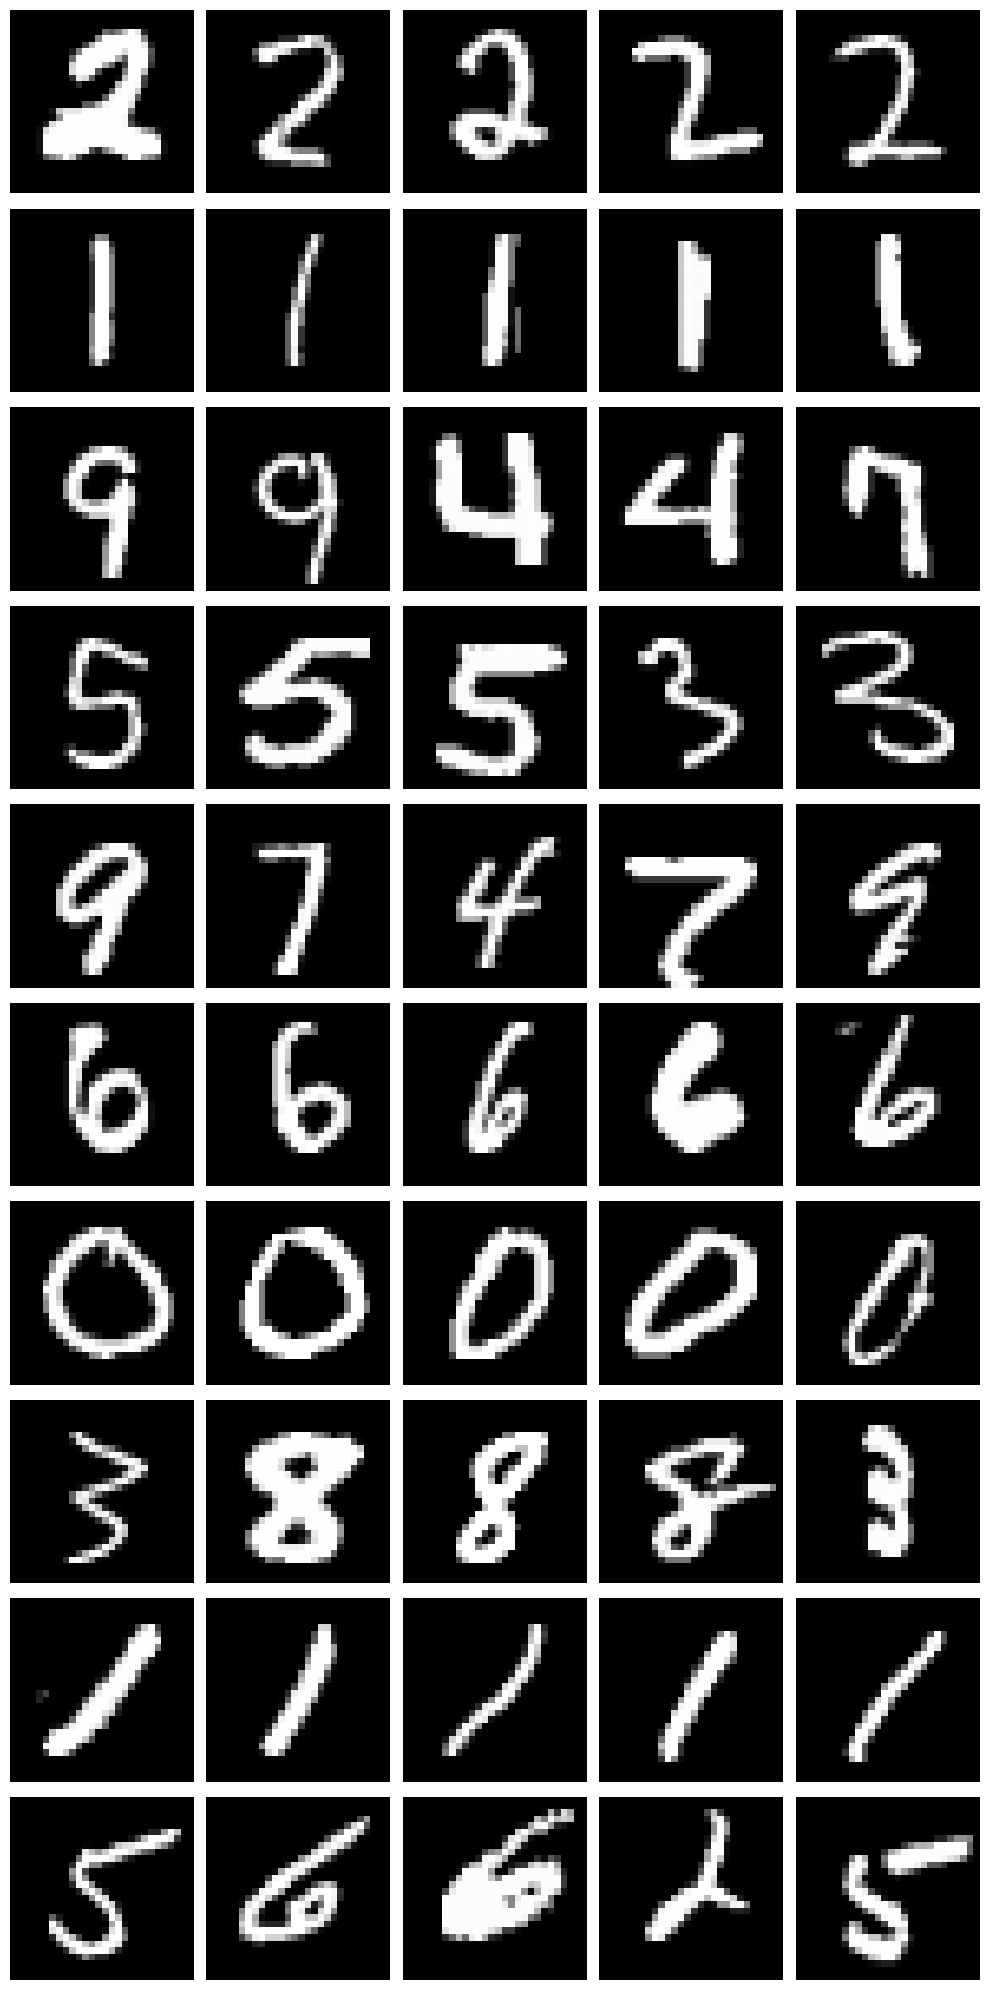

In [ ]:
# output best
n_clusters_best = best_n_gmm
plot_clusters_images(X_train, train_labels_gmm, n_clusters_best, n_per_cluster=5)


In [ ]:
# Compute an extended set of clustering evaluation metrics.
# These additional scores (e.g. homogeneity, completeness, V-measure)
# the primary metric for model selection.

from sklearn.metrics import (
    homogeneity_score,
    completeness_score,
    v_measure_score,
    fowlkes_mallows_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

def eval_clustering_extended(X, y_true, y_pred):
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    sil = silhouette_score(X, y_pred)

    hom = homogeneity_score(y_true, y_pred)
    comp = completeness_score(y_true, y_pred)
    v_meas = v_measure_score(y_true, y_pred)
    fmi = fowlkes_mallows_score(y_true, y_pred)

    ch = calinski_harabasz_score(X, y_pred)
    db = davies_bouldin_score(X, y_pred)

    return {
        "ARI": ari,
        "NMI": nmi,
        "Silhouette": sil,
        "Homogeneity": hom,
        "Completeness": comp,
        "V_measure": v_meas,
        "Fowlkes_Mallows": fmi,
        "Calinski_Harabasz": ch,
        "Davies_Bouldin": db,
    }

print("Best KMeans extended metrics:")
print("  Train:", eval_clustering_extended(Xtr_best_km, y_train, train_labels_km))
print("  Test :", eval_clustering_extended(Xte_best_km, y_test,  test_labels_km))

print("\nBest GMM extended metrics:")
print("  Train:", eval_clustering_extended(Xtr_best_gmm, y_train, train_labels_gmm))
print("  Test :", eval_clustering_extended(Xte_best_gmm, y_test,  test_labels_gmm))

Best KMeans extended metrics:
  Train: {'ARI': 0.3784940898382149, 'NMI': 0.5366225570029959, 'Silhouette': 0.07518584281206131, 'Homogeneity': 0.580973774873884, 'Completeness': 0.49856256545267086, 'V_measure': 0.5366225570029958, 'Fowlkes_Mallows': 0.4366800135094023, 'Calinski_Harabasz': 1972.5047607421875, 'Davies_Bouldin': 2.635262740105163}
  Test : {'ARI': 0.3801768855019568, 'NMI': 0.5379612483682102, 'Silhouette': 0.07774430513381958, 'Homogeneity': 0.5825343113240419, 'Completeness': 0.49972444622750944, 'V_measure': 0.5379612483682105, 'Fowlkes_Mallows': 0.43824019024508937, 'Calinski_Harabasz': 502.6671142578125, 'Davies_Bouldin': 2.6041706763307984}

Best GMM extended metrics:
  Train: {'ARI': 0.48779464752013224, 'NMI': 0.6366273077920044, 'Silhouette': 0.09046421945095062, 'Homogeneity': 0.6285865051264411, 'Completeness': 0.6448764899765947, 'V_measure': 0.6366273077920044, 'Fowlkes_Mallows': 0.542657500640386, 'Calinski_Harabasz': 3345.97216796875, 'Davies_Bouldin': 2

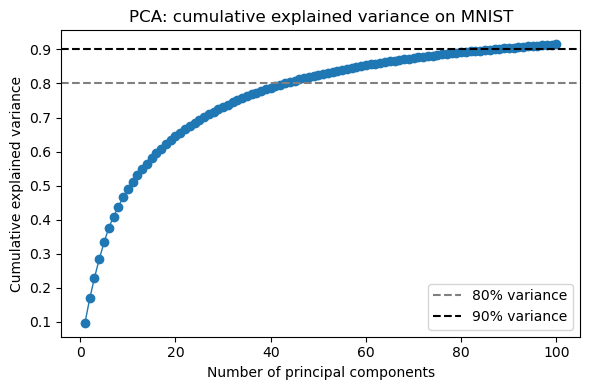

In [ ]:
# PCA explained variance curve
from sklearn.decomposition import PCA as PCA_curve

pca_curve = PCA_curve(n_components=100, random_state=42)
pca_curve.fit(X_train)

cum_explained = np.cumsum(pca_curve.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_explained)+1), cum_explained, marker="o", linewidth=1)
plt.axhline(0.8, linestyle="--", color="gray", label="80% variance")
plt.axhline(0.9, linestyle="--", color="black", label="90% variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA: cumulative explained variance on MNIST")
plt.legend()
plt.tight_layout()
plt.show()

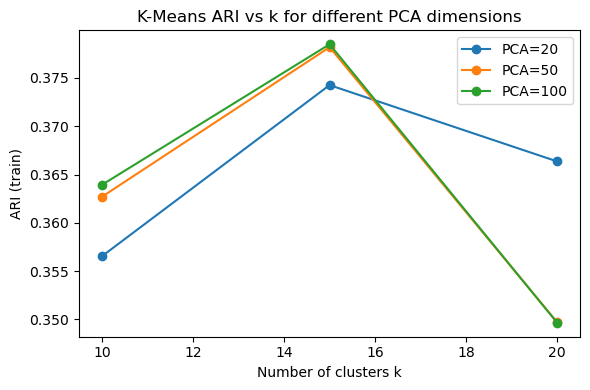

In [ ]:
# KMeans ARI vs k for each PCA dimension chose for report
plt.figure(figsize=(6,4))

for n_dim in pca_dims_list:
    ks = [d["n_clusters"] for d in kmeans_results if d["pca_dims"] == n_dim]
    aris = [d["ARI"] for d in kmeans_results if d["pca_dims"] == n_dim]
    plt.plot(ks, aris, marker="o", label=f"PCA={n_dim}")

plt.xlabel("Number of clusters k")
plt.ylabel("ARI (train)")
plt.title("K-Means ARI vs k for different PCA dimensions")
plt.legend()
plt.tight_layout()
plt.show()

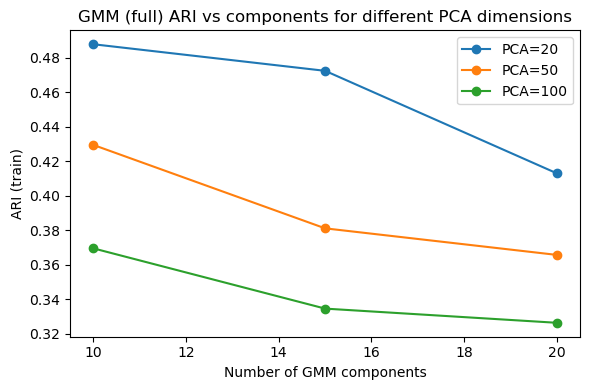

In [ ]:
# GMM ARI vs components (full covariance only)
plt.figure(figsize=(6,4))

for n_dim in pca_dims_list:
    comps = [
        d["n_components"]
        for d in gmm_results
        if d["pca_dims"] == n_dim and d["covariance_type"] == "full"
    ]
    aris = [
        d["ARI"]
        for d in gmm_results
        if d["pca_dims"] == n_dim and d["covariance_type"] == "full"
    ]
    plt.plot(comps, aris, marker="o", label=f"PCA={n_dim}")

plt.xlabel("Number of GMM components")
plt.ylabel("ARI (train)")
plt.title("GMM (full) ARI vs components for different PCA dimensions")
plt.legend()
plt.tight_layout()
plt.show()

Confusion matrix shape: (10, 10)
Overall purity (test): 0.673
Majority label per cluster: [2 1 4 3 7 6 0 8 1 5]


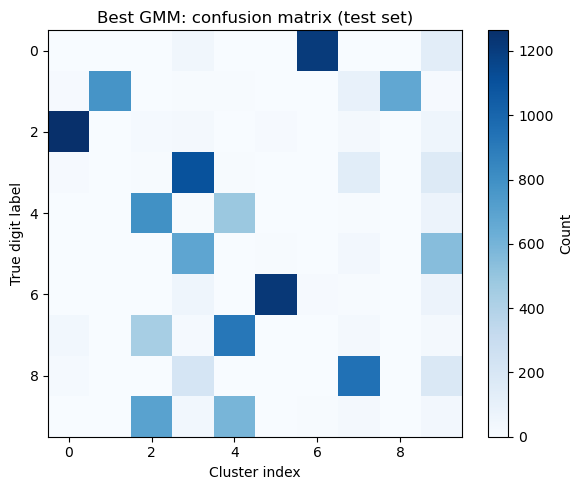

In [ ]:
#  Confusion matrix and purity for best GMM (test set)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_labels_gmm, labels=np.arange(best_n_gmm))
print("Confusion matrix shape:", cm.shape)

cluster_max = cm.max(axis=0)   # max label count per cluster
overall_purity = cluster_max.sum() / cm.sum()
print(f"Overall purity (test): {overall_purity:.3f}")

majority_labels = cm.argmax(axis=0)
print("Majority label per cluster:", majority_labels)

plt.figure(figsize=(6,5))
plt.imshow(cm, aspect="auto", cmap="Blues")
plt.colorbar(label="Count")
plt.xlabel("Cluster index")
plt.ylabel("True digit label")
plt.title("Best GMM: confusion matrix (test set)")
plt.tight_layout()
plt.show()

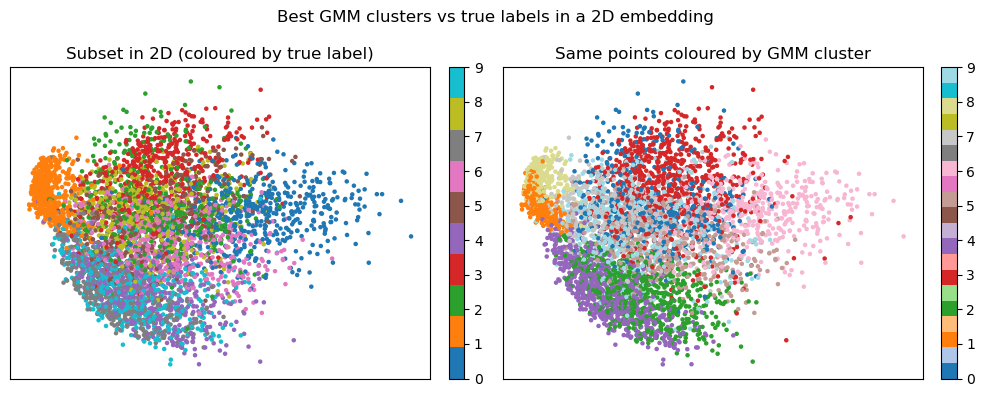

In [ ]:
# Visualise the best GMM clustering.
from sklearn.decomposition import PCA as PCA2D

n_vis = 5000
idx_vis = np.random.choice(X_train.shape[0], size=n_vis, replace=False)
X_vis = X_train[idx_vis]
y_vis = y_train[idx_vis]

X_vis_pca = pca_gmm.transform(X_vis)
gmm_labels_vis = gmm_best.predict(X_vis_pca)

pca_vis = PCA2D(n_components=2, random_state=42)
X_vis_2d = pca_vis.fit_transform(X_vis_pca)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sc0 = axes[0].scatter(X_vis_2d[:,0], X_vis_2d[:,1],
                      c=y_vis, s=5, cmap="tab10")
axes[0].set_title("Subset in 2D (coloured by true label)")
axes[0].set_xticks([])
axes[0].set_yticks([])
plt.colorbar(sc0, ax=axes[0], fraction=0.046, pad=0.04)

sc1 = axes[1].scatter(X_vis_2d[:,0], X_vis_2d[:,1],
                      c=gmm_labels_vis, s=5, cmap="tab20")
axes[1].set_title("Same points coloured by GMM cluster")
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.colorbar(sc1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("Best GMM clusters vs true labels in a 2D embedding")
plt.tight_layout()
plt.show()

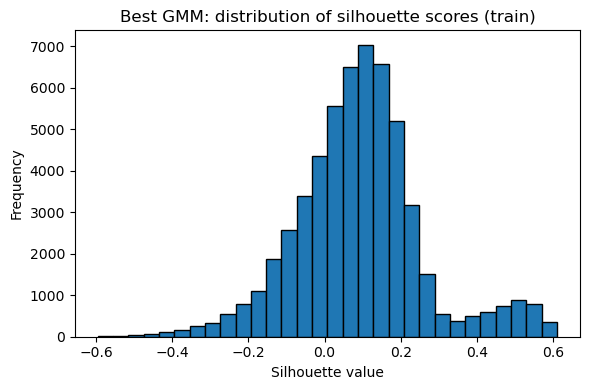

In [ ]:
#Silhouette distribution for best GMM (train set)
from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(Xtr_best_gmm, train_labels_gmm)

plt.figure(figsize=(6,4))
plt.hist(sil_samples, bins=30, edgecolor="black")
plt.xlabel("Silhouette value")
plt.ylabel("Frequency")
plt.title("Best GMM: distribution of silhouette scores (train)")
plt.tight_layout()
plt.show()